<a href="https://colab.research.google.com/github/RegiRezende/MathCode/blob/Python_codes/FDM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


📐 MALHA: 21 x 21 = 441 pontos totais
📍 Pontos internos: 19 x 19 = 361

🔧 Resolvendo abordagem 1 (sistema completo)...
🔧 Resolvendo abordagem 2 (sistema reduzido)...

🎨 Gerando visualizações das matrizes em quadradinhos...


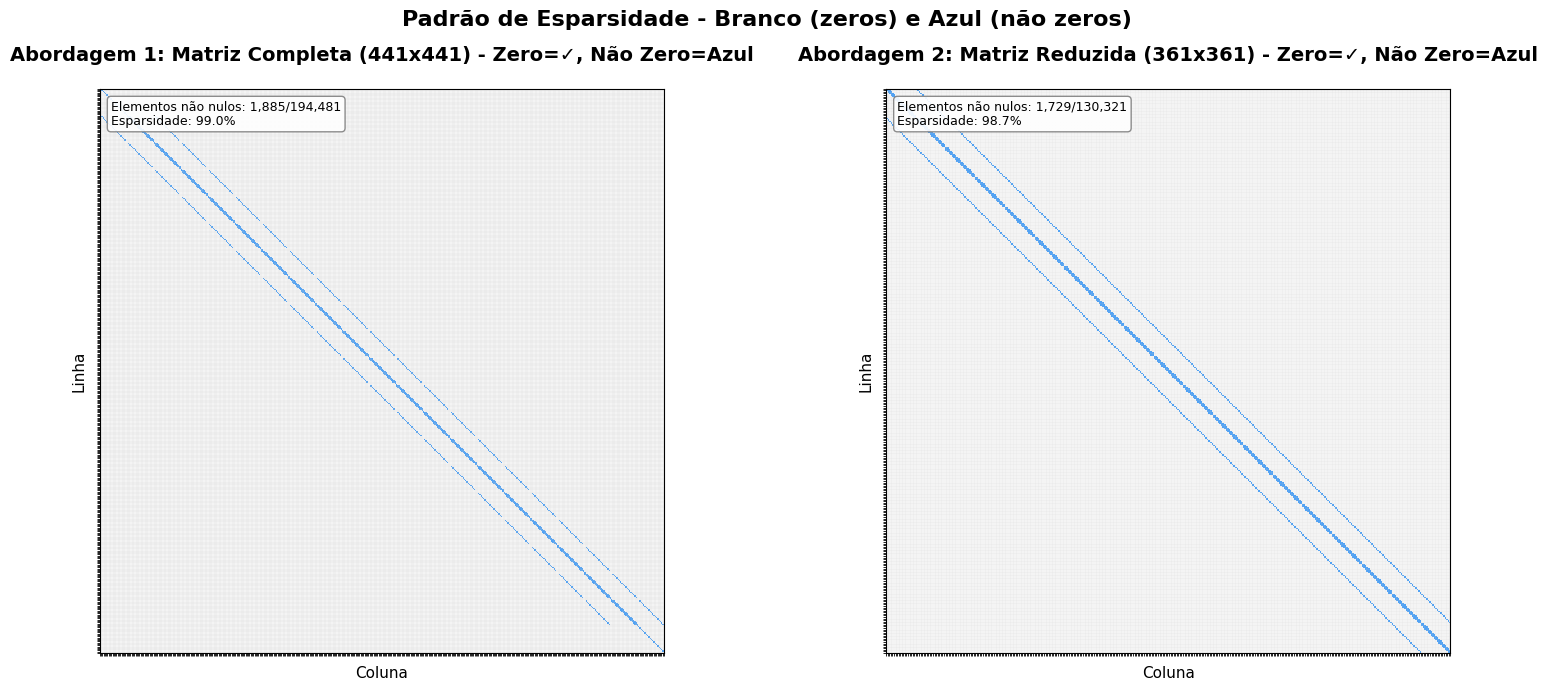

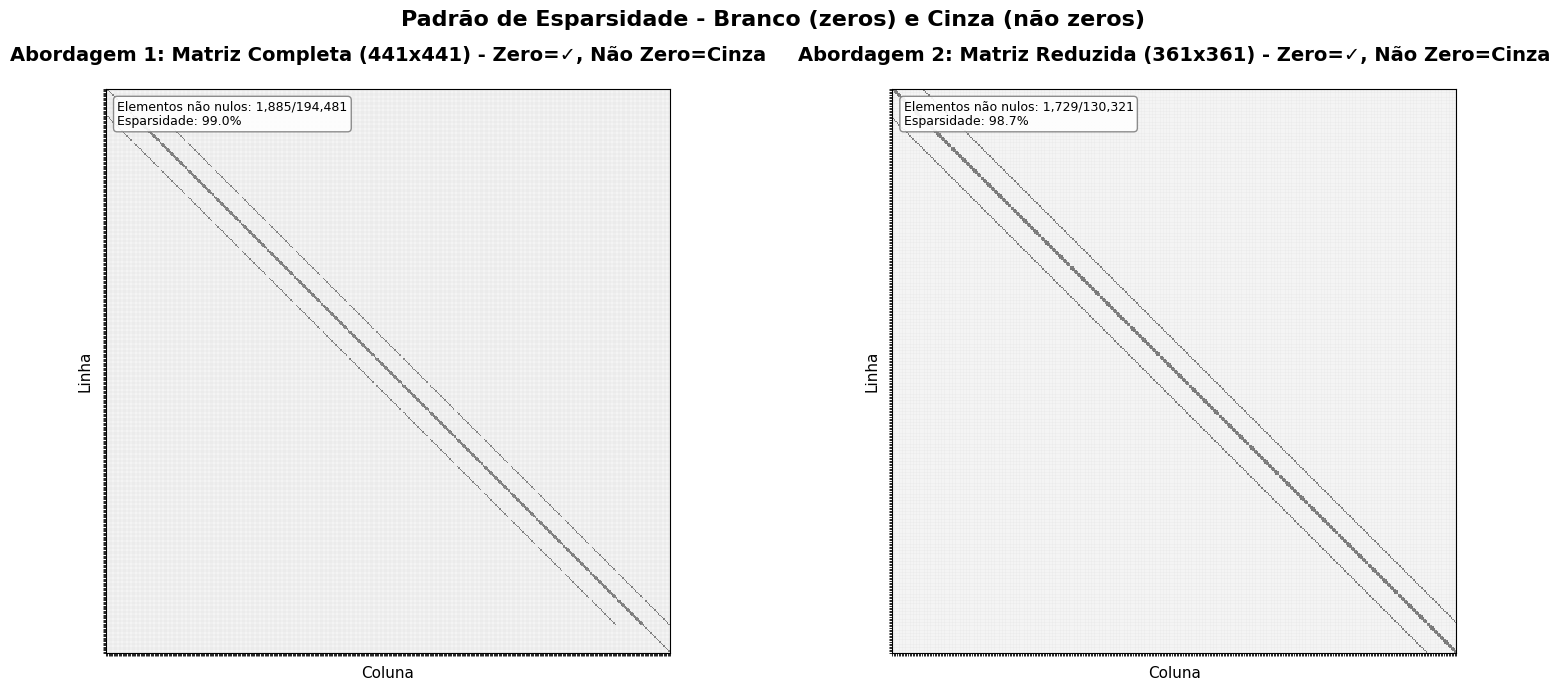


📈 ANÁLISE NUMÉRICA COMPLETA

📊 ANÁLISE DA MATRIZ - Abordagem 1 (Completa - 441x441)

📐 Dimensão: 441x441
🔢 Elementos totais: 194,481
✅ Elementos não nulos: 1,885
⬜ Elementos nulos: 192,596
📊 Esparsidade: 99.03%
📊 Densidade: 0.97%

⚠️  Número de condicionamento (2-norma): 7.97e+03
   ✓ Condicionamento aceitável

🎵 Autovalores (amostra dos 5 maiores e menores):
   Mínimo: 1.000000e+00
   Máximo: 3.180301e+03
   Média: 1.309932e+03

📏 Normas:
   Norma 1: 3.200000e+03
   Norma Frobenius: 3.398823e+04
   Norma infinita: 3.200000e+03

📊 ANÁLISE DA MATRIZ - Abordagem 2 (Reduzida - 361x361)

📐 Dimensão: 361x361
🔢 Elementos totais: 130,321
✅ Elementos não nulos: 1,729
⬜ Elementos nulos: 128,592
📊 Esparsidade: 98.67%
📊 Densidade: 1.33%

⚠️  Número de condicionamento (2-norma): 1.61e+02
   ✓ Condicionamento aceitável

🎵 Autovalores (amostra dos 5 maiores e menores):
   Mínimo: 1.969866e+01
   Máximo: 3.180301e+03
   Média: 1.600000e+03

📏 Normas:
   Norma 1: 3.200000e+03
   Norma Frobenius: 3.38

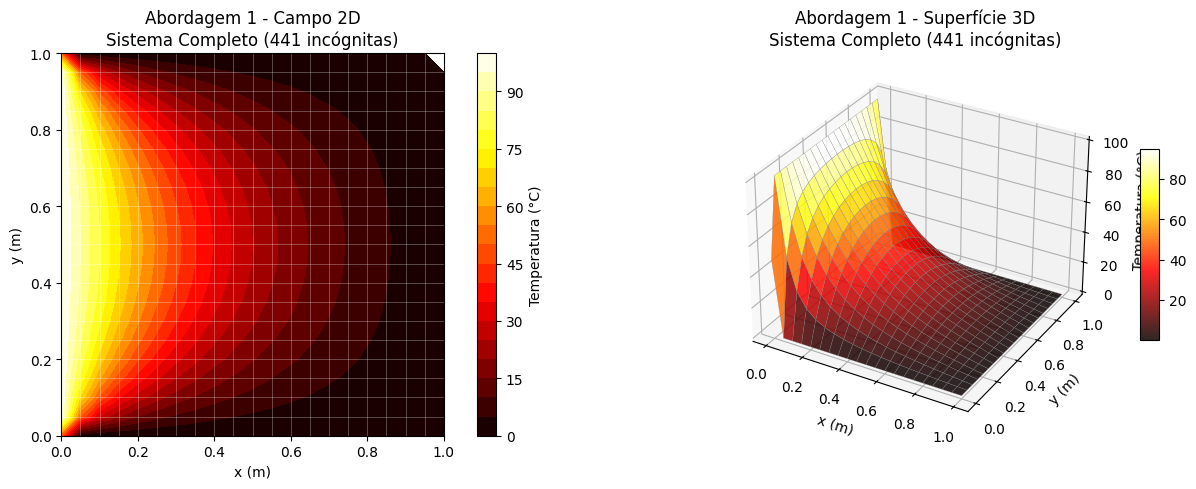

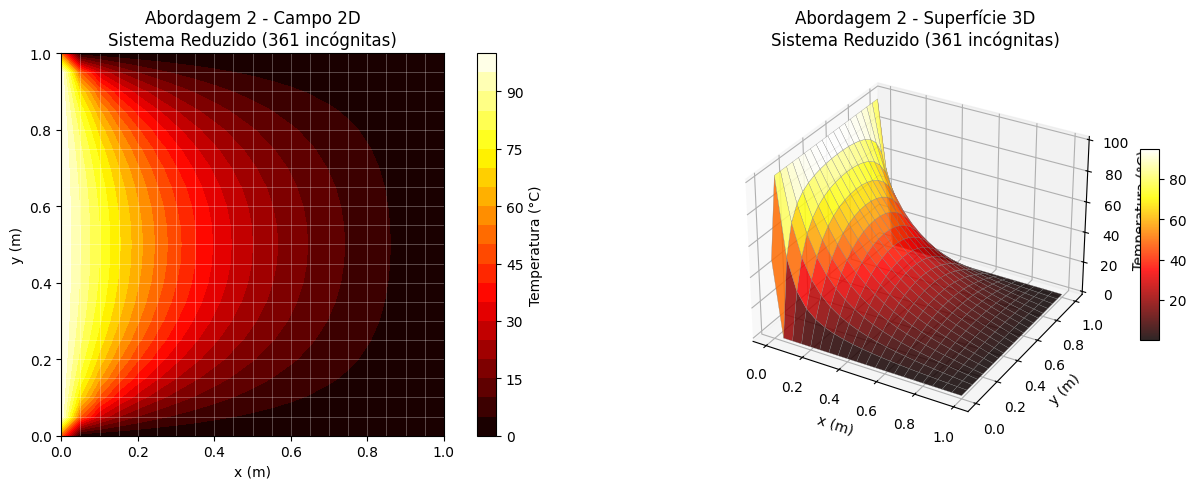


📈 COMPARAÇÃO FINAL ENTRE ABORDAGENS

Característica                      Abordagem 1 (Completa)    Abordagem 2 (Reduzida)   
-------------------------------------------------------------------------------------
Dimensão da matriz                  441x441                   361x361                  
Número de incógnitas                441                       361                      
Redução no problema                 -                         18.1% menor
Elementos não nulos                 1,885                     1,729                    
Esparsidade                         99.0%                     98.7%
Densidade                           1.0%                     1.3%
Condicionamento                     7.97e+03                   1.61e+02
Melhora no condicionamento          -                         49.4x melhor

❌ VERIFICAÇÃO NUMÉRICA: Campos diferentes!
   Diferença máxima: 3.72e-11

🎯 RECOMENDAÇÃO FINAL

Para a malha 21x21 analisada:

📊 ABORDAGEM 1 (Sistema Completo):
   • Ma

In [47]:
# =============================================================================
# Solução da euqção da conduição em 2D usando duas abordagens matriciais diferentes
# =============================================================================



import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import scipy.linalg as la
from matplotlib.colors import LinearSegmentedColormap

# =============================================================================
# PARÂMETROS DO PROBLEMA - MALHA 21x21
# =============================================================================
Ni = 21          # número de pontos em x
Nj = 21          # número de pontos em y
Lx = 1.0        # comprimento em x
Ly = 1.0        # comprimento em y

# Condições de contorno
T_esq = 100.0
T_dir = 0.0
T_inf = 0.0
T_sup = 0.0

print(f"\n{'='*70}")
print(f"📐 MALHA: {Ni} x {Nj} = {Ni*Nj} pontos totais")
print(f"📍 Pontos internos: {(Ni-2)} x {(Nj-2)} = {(Ni-2)*(Nj-2)}")
print(f"{'='*70}")

# =============================================================================
# DISCRETIZAÇÃO
# =============================================================================
dx = Lx / (Ni - 1)
dy = Ly / (Nj - 1)

# Cantos: média entre as duas bordas
canto_esq_inf = (T_esq + T_inf) / 2.0
canto_esq_sup = (T_esq + T_sup) / 2.0
canto_dir_inf = (T_dir + T_inf) / 2.0
canto_dir_sup = (T_dir + T_sup) / 2.0

# Coordenadas dos nós
x = np.linspace(0, Lx, Ni)
y = np.linspace(0, Ly, Nj)
X, Y = np.meshgrid(x, y)

# =============================================================================
# ABORDAGEM 1: Sistema completo (N x N) com nós de fronteira fixos
# =============================================================================
N = Ni * Nj
A1 = np.zeros((N, N))
b1 = np.zeros(N)

# Mapeamento (i,j) -> índice global (ordem linha por y)
def idx(i, j):
    return j * Ni + i

# Preenche a matriz
for j in range(Nj):
    for i in range(Ni):
        p = idx(i, j)
        # Verifica se é nó de fronteira (inclui cantos)
        if i == 0 or i == Ni-1 or j == 0 or j == Nj-1:
            A1[p, p] = 1.0
            # Atribui valor de contorno
            if i == 0 and j == 0:
                b1[p] = canto_esq_inf
            elif i == 0 and j == Nj-1:
                b1[p] = canto_esq_sup
            elif i == Ni-1 and j == 0:
                b1[p] = canto_dir_inf
            elif i == Ni-1 and j == Nj-1:
                b1[p] = canto_dir_sup
            elif i == 0:
                b1[p] = T_esq
            elif i == Ni-1:
                b1[p] = T_dir
            elif j == 0:
                b1[p] = T_inf
            elif j == Nj-1:
                b1[p] = T_sup
        else:
            # Nó interno: discretização 5 pontos
            coeff_x = 1.0/dx**2
            coeff_y = 1.0/dy**2
            A1[p, p] = 2.0 * (coeff_x + coeff_y)   # Ap
            A1[p, idx(i+1, j)] = -coeff_x           # Ae
            A1[p, idx(i-1, j)] = -coeff_x           # Aw
            A1[p, idx(i, j+1)] = -coeff_y           # An
            A1[p, idx(i, j-1)] = -coeff_y           # As
            b1[p] = 0.0

# Resolve o sistema
print("\n🔧 Resolvendo abordagem 1 (sistema completo)...")
T1 = la.solve(A1, b1).reshape((Nj, Ni))

# =============================================================================
# ABORDAGEM 2: Sistema apenas para nós internos
# =============================================================================
# Índices dos nós internos (i=1..Ni-2, j=1..Nj-2)
internos = []
for j in range(1, Nj-1):
    for i in range(1, Ni-1):
        internos.append((i, j))

Nin = len(internos)   # = (Ni-2)*(Nj-2)
A2 = np.zeros((Nin, Nin))
b2 = np.zeros(Nin)

# Mapeamento local dos internos
map_int = { (i,j): k for k, (i,j) in enumerate(internos) }

# Coeficientes
ax = 1.0/dx**2
ay = 1.0/dy**2
ap = 2.0*(ax + ay)

# Monta o sistema
print("🔧 Resolvendo abordagem 2 (sistema reduzido)...")
for (i,j) in internos:
    p = map_int[(i,j)]
    A2[p, p] = ap
    # Termos que dependem dos vizinhos
    # Vizinho Leste
    if i+1 == Ni-1:   # fronteira direita
        b2[p] += ax * T_dir
    elif (i+1, j) in map_int:
        A2[p, map_int[(i+1, j)]] -= ax
    # Vizinho Oeste
    if i-1 == 0:      # fronteira esquerda
        b2[p] += ax * T_esq
    elif (i-1, j) in map_int:
        A2[p, map_int[(i-1, j)]] -= ax
    # Vizinho Norte
    if j+1 == Nj-1:   # fronteira superior
        b2[p] += ay * T_sup
    elif (i, j+1) in map_int:
        A2[p, map_int[(i, j+1)]] -= ay
    # Vizinho Sul
    if j-1 == 0:      # fronteira inferior
        b2[p] += ay * T_inf
    elif (i, j-1) in map_int:
        A2[p, map_int[(i, j-1)]] -= ay

# Resolve para os internos
T_int = la.solve(A2, b2)

# Reconstrói o campo completo
T2 = np.zeros((Nj, Ni))

# Primeiro, contornos (incluindo cantos)
for j in range(Nj):
    for i in range(Ni):
        if i == 0 and j == 0:
            T2[j, i] = canto_esq_inf
        elif i == 0 and j == Nj-1:
            T2[j, i] = canto_esq_sup
        elif i == Ni-1 and j == 0:
            T2[j, i] = canto_dir_inf
        elif i == Ni-1 and j == Nj-1:
            T2[j, i] = canto_dir_sup
        elif i == 0:
            T2[j, i] = T_esq
        elif i == Ni-1:
            T2[j, i] = T_dir
        elif j == 0:
            T2[j, i] = T_inf
        elif j == Nj-1:
            T2[j, i] = T_sup

# Preenche os internos
for k, (i, j) in enumerate(internos):
    T2[j, i] = T_int[k]

# =============================================================================
# VISUALIZAÇÃO DO PADRÃO DE ESPARSIDADE - CORES PURAS (BRANCO PARA ZEROS)
# =============================================================================
def plot_sparsity_blue_white(A, title, ax=None):
    """Padrão de esparsidade: ZERO = BRANCO, NÃO ZERO = AZUL CLARO"""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))

    n = A.shape[0]
    pattern = np.zeros((n, n))
    pattern[A != 0] = 1

    # Branco para zeros, azul claro para não zeros
    cmap = LinearSegmentedColormap.from_list('blue_white', ['#ffffff', '#3399ff'], N=2)

    im = ax.imshow(pattern, cmap=cmap, interpolation='nearest', aspect='equal')

    # Gridlines sutis
    ax.set_xticks(np.arange(-0.5, n, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n, 1), minor=True)
    ax.grid(which='minor', color='#cccccc', linestyle='-', linewidth=0.3, alpha=0.5)

    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    ax.set_xlabel('Coluna', fontsize=11)
    ax.set_ylabel('Linha', fontsize=11)
    ax.set_xticks([])
    ax.set_yticks([])

    # Informações de esparsidade
    n_nonzero = np.count_nonzero(A)
    n_total = n * n
    sparsity = 100 * (1 - n_nonzero / n_total)

    textstr = f'Elementos não nulos: {n_nonzero:,}/{n_total:,}\nEsparsidade: {sparsity:.1f}%'
    ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))

    return ax

def plot_sparsity_gray_white(A, title, ax=None):
    """Padrão de esparsidade: ZERO = BRANCO, NÃO ZERO = CINZA"""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))

    n = A.shape[0]
    pattern = np.zeros((n, n))
    pattern[A != 0] = 1

    # Branco para zeros, cinza para não zeros
    cmap = LinearSegmentedColormap.from_list('gray_white', ['#ffffff', '#666666'], N=2)

    im = ax.imshow(pattern, cmap=cmap, interpolation='nearest', aspect='equal')

    # Gridlines sutis
    ax.set_xticks(np.arange(-0.5, n, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n, 1), minor=True)
    ax.grid(which='minor', color='#cccccc', linestyle='-', linewidth=0.3, alpha=0.5)

    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    ax.set_xlabel('Coluna', fontsize=11)
    ax.set_ylabel('Linha', fontsize=11)
    ax.set_xticks([])
    ax.set_yticks([])

    # Informações de esparsidade
    n_nonzero = np.count_nonzero(A)
    n_total = n * n
    sparsity = 100 * (1 - n_nonzero / n_total)

    textstr = f'Elementos não nulos: {n_nonzero:,}/{n_total:,}\nEsparsidade: {sparsity:.1f}%'
    ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))

    return ax

# =============================================================================
# VISUALIZAÇÃO DAS MATRIZES EM QUADRADINHOS
# =============================================================================
print("\n🎨 Gerando visualizações das matrizes em quadradinhos...")

# Figura 1: Estilo Azul e Branco (mais limpo)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
plot_sparsity_blue_white(A1, f'Abordagem 1: Matriz Completa ({N}x{N}) - Zero=✓, Não Zero=Azul', axes[0])
plot_sparsity_blue_white(A2, f'Abordagem 2: Matriz Reduzida ({Nin}x{Nin}) - Zero=✓, Não Zero=Azul', axes[1])
plt.suptitle('Padrão de Esparsidade - Branco (zeros) e Azul (não zeros)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Figura 2: Estilo Cinza e Branco (alternativa)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
plot_sparsity_gray_white(A1, f'Abordagem 1: Matriz Completa ({N}x{N}) - Zero=✓, Não Zero=Cinza', axes[0])
plot_sparsity_gray_white(A2, f'Abordagem 2: Matriz Reduzida ({Nin}x{Nin}) - Zero=✓, Não Zero=Cinza', axes[1])
plt.suptitle('Padrão de Esparsidade - Branco (zeros) e Cinza (não zeros)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# =============================================================================
# ANÁLISE NUMÉRICA DETALHADA
# =============================================================================
def analise_completa_matriz(A, nome):
    print(f"\n{'='*70}")
    print(f"📊 ANÁLISE DA MATRIZ - {nome}")
    print(f"{'='*70}")

    n = A.shape[0]
    n_nonzero = np.count_nonzero(A)
    n_total = n * n

    print(f"\n📐 Dimensão: {n}x{n}")
    print(f"🔢 Elementos totais: {n_total:,}")
    print(f"✅ Elementos não nulos: {n_nonzero:,}")
    print(f"⬜ Elementos nulos: {n_total - n_nonzero:,}")
    print(f"📊 Esparsidade: {100 * (1 - n_nonzero/n_total):.2f}%")
    print(f"📊 Densidade: {100 * n_nonzero/n_total:.2f}%")

    # Número de condicionamento
    cond_num = np.linalg.cond(A)
    print(f"\n⚠️  Número de condicionamento (2-norma): {cond_num:.2e}")
    if cond_num > 1e10:
        print("   ⚠️  Matriz mal condicionada - resultados podem ser instáveis!")
    elif cond_num > 1e5:
        print("   ⚠️  Condicionamento moderado - cuidado com erros numéricos")
    else:
        print("   ✓ Condicionamento aceitável")

    # Autovalores (amostra para matrizes grandes)
    print(f"\n🎵 Autovalores (amostra dos 5 maiores e menores):")
    try:
        eigvals = np.linalg.eigvals(A)
        eigvals_real = np.real(eigvals)
        eigvals_sorted = np.sort(eigvals_real)
        print(f"   Mínimo: {eigvals_sorted[0]:.6e}")
        print(f"   Máximo: {eigvals_sorted[-1]:.6e}")
        print(f"   Média: {np.mean(eigvals_real):.6e}")
    except:
        print("   (Cálculo de autovalores omitido para matriz muito grande)")

    # Normas
    print(f"\n📏 Normas:")
    print(f"   Norma 1: {np.linalg.norm(A, 1):.6e}")
    print(f"   Norma Frobenius: {np.linalg.norm(A, 'fro'):.6e}")
    print(f"   Norma infinita: {np.linalg.norm(A, np.inf):.6e}")

    return cond_num

# Análise das duas matrizes
print("\n" + "="*70)
print("📈 ANÁLISE NUMÉRICA COMPLETA")
print("="*70)

cond1 = analise_completa_matriz(A1, f"Abordagem 1 (Completa - {N}x{N})")
cond2 = analise_completa_matriz(A2, f"Abordagem 2 (Reduzida - {Nin}x{Nin})")

# =============================================================================
# PLOTS DO CAMPO DE TEMPERATURA - AMBAS AS ABORDAGENS
# =============================================================================
def plota_campo_2d_3d(T, X, Y, titulo, subtitulo):
    fig = plt.figure(figsize=(14, 5))

    # Plot 2D com contourf
    ax1 = fig.add_subplot(121)
    cf = ax1.contourf(X, Y, T, levels=20, cmap='hot')
    plt.colorbar(cf, ax=ax1, label='Temperatura (°C)')

    # Sobreposição do grid da malha com transparência
    for i in range(Ni):
        ax1.axvline(x=x[i], color='white', linestyle='-', linewidth=0.5, alpha=0.4)
    for j in range(Nj):
        ax1.axhline(y=y[j], color='white', linestyle='-', linewidth=0.5, alpha=0.4)

    ax1.set_title(f'{titulo} - Campo 2D\n{subtitulo}', fontsize=12)
    ax1.set_xlabel('x (m)')
    ax1.set_ylabel('y (m)')
    ax1.set_aspect('equal')

    # Plot 3D
    ax2 = fig.add_subplot(122, projection='3d')
    surf = ax2.plot_surface(X, Y, T, cmap='hot', edgecolor='gray', linewidth=0.2, alpha=0.85)
    ax2.set_title(f'{titulo} - Superfície 3D\n{subtitulo}', fontsize=12)
    ax2.set_xlabel('x (m)')
    ax2.set_ylabel('y (m)')
    ax2.set_zlabel('Temperatura (°C)')
    plt.colorbar(surf, ax=ax2, shrink=0.5, aspect=10)

    plt.tight_layout()
    plt.show()

print("\n🌡️ Gerando visualizações do campo de temperatura...")

# Plot da Abordagem 1
plota_campo_2d_3d(T1, X, Y, "Abordagem 1", f"Sistema Completo ({N} incógnitas)")

# Plot da Abordagem 2
plota_campo_2d_3d(T2, X, Y, "Abordagem 2", f"Sistema Reduzido ({Nin} incógnitas)")

# =============================================================================
# COMPARAÇÃO FINAL DETALHADA
# =============================================================================
print("\n" + "="*70)
print("📈 COMPARAÇÃO FINAL ENTRE ABORDAGENS")
print("="*70)

print(f"\n{'Característica':<35} {'Abordagem 1 (Completa)':<25} {'Abordagem 2 (Reduzida)':<25}")
print("-"*85)
print(f"{'Dimensão da matriz':<35} {f'{N}x{N}':<25} {f'{Nin}x{Nin}':<25}")
print(f"{'Número de incógnitas':<35} {N:<25,} {Nin:<25,}")
print(f"{'Redução no problema':<35} {'-':<25} {(1 - Nin/N)*100:.1f}% menor")
print(f"{'Elementos não nulos':<35} {np.count_nonzero(A1):<25,} {np.count_nonzero(A2):<25,}")
print(f"{'Esparsidade':<35} {100*(1 - np.count_nonzero(A1)/A1.size):.1f}%{'':<20} {100*(1 - np.count_nonzero(A2)/A2.size):.1f}%")
print(f"{'Densidade':<35} {100*np.count_nonzero(A1)/A1.size:.1f}%{'':<20} {100*np.count_nonzero(A2)/A2.size:.1f}%")
print(f"{'Condicionamento':<35} {cond1:.2e}{'':<18} {cond2:.2e}")
print(f"{'Melhora no condicionamento':<35} {'-':<25} {cond1/cond2:.1f}x melhor")

# Verifica concordância
if np.allclose(T1, T2, rtol=1e-10, atol=1e-12):
    diff_max = np.max(np.abs(T1-T2))
    print(f"\n✅ VERIFICAÇÃO NUMÉRICA: Campos de temperatura IDÊNTICOS")
    print(f"   Diferença máxima entre as soluções: {diff_max:.2e}")
    print(f"   As duas abordagens produzem o mesmo resultado físico!")
else:
    diff_max = np.max(np.abs(T1-T2))
    print(f"\n❌ VERIFICAÇÃO NUMÉRICA: Campos diferentes!")
    print(f"   Diferença máxima: {diff_max:.2e}")

print("\n" + "="*70)
print("🎯 RECOMENDAÇÃO FINAL")
print("="*70)

print(f"\nPara a malha {Ni}x{Nj} analisada:")
print(f"\n📊 ABORDAGEM 1 (Sistema Completo):")
print(f"   • Matriz {N}x{N} com {N:,} incógnitas")
print(f"   • Inclui todos os {2*(Ni+Nj)-4} nós de fronteira como variáveis")
print(f"   • Alta esparsidade ({100*(1 - np.count_nonzero(A1)/A1.size):.1f}% zeros)")
print(f"   • Condicionamento: {cond1:.2e}")

print(f"\n📊 ABORDAGEM 2 (Sistema Reduzido):")
print(f"   • Matriz {Nin}x{Nin} com apenas {Nin:,} incógnitas")
print(f"   • Elimina os {N - Nin:,} nós de fronteira")
print(f"   • Matriz com densidade de {100*np.count_nonzero(A2)/A2.size:.1f}%")
print(f"   • Condicionamento: {cond2:.2e} ({cond1/cond2:.1f}x melhor que a Abordagem 1)")

print(f"\n✅ CONCLUSÃO: A ABORDAGEM 2 é SUPERIOR para esta malha pois:")
print(f"   • Reduz o número de incógnitas em {(1 - Nin/N)*100:.1f}%")
print(f"   • Melhora o condicionamento em {cond1/cond2:.1f} vezes")
print(f"   • Matriz com coeficientes mais uniformes (todos da mesma ordem de magnitude)")
print(f"   • Mais eficiente computacionalmente, especialmente para malhas maiores")

print("\n" + "="*70)

In [48]:
# ======================================================================
# COMPARAÇÃO DE TEMPOS DE COOMPUTAÇÃO ITERATIVA E DIRETA
# ======================================================================


import numpy as np
import scipy.sparse as sp
from scipy.sparse.linalg import gmres, spsolve
import time

# ======================================================================
# CONFIGURAÇÃO DO PROBLEMA
# ======================================================================

n = 21  # pontos por dimensão
Lx = 1.0
Ly = 1.0

dx = Lx / (n - 1)
dy = Ly / (n - 1)

coeff_x = 1.0 / dx**2
coeff_y = 1.0 / dy**2
ap = 2.0 * (coeff_x + coeff_y)  # coeficiente central

N_internos = (n-2) * (n-2)
N_total = n * n

print("="*70)
print(f"📐 MALHA: {n} x {n} = {N_total} pontos totais")
print(f"📍 Pontos internos: {n-2} x {n-2} = {N_internos}")
print(f"📏 dx = {dx:.6f}, dy = {dy:.6f}")
print(f"🔢 Coeficientes: ax = {coeff_x:.2f}, ay = {coeff_y:.2f}, ap = {ap:.2f}")
print("="*70)

# ======================================================================
# MONTAGEM DA MATRIZ - ABORDAGEM 1 (SISTEMA COMPLETO)
# ======================================================================

def montar_matriz_completa(n, coeff_x, coeff_y, ap):
    """Monta matriz incluindo nós de fronteira"""
    N = n * n
    A = sp.lil_matrix((N, N))
    b = np.zeros(N)

    def idx(i, j):
        return j * n + i  # ordem linha por y (como no seu código)

    for j in range(n):
        for i in range(n):
            p = idx(i, j)

            # Fronteira: valor constante
            if i == 0 or i == n-1 or j == 0 or j == n-1:
                A[p, p] = 1.0

                # Atribui valores de contorno (como no seu código)
                if i == 0 and j == 0:
                    b[p] = 100.0  # canto esq-inf
                elif i == 0 and j == n-1:
                    b[p] = 100.0  # canto esq-sup
                elif i == n-1 and j == 0:
                    b[p] = 0.0    # canto dir-inf
                elif i == n-1 and j == n-1:
                    b[p] = 0.0    # canto dir-sup
                elif i == 0:
                    b[p] = 100.0  # T_esq
                elif i == n-1:
                    b[p] = 0.0    # T_dir
                elif j == 0:
                    b[p] = 0.0    # T_inf
                elif j == n-1:
                    b[p] = 0.0    # T_sup
            else:
                # Nó interno: discretização 5 pontos
                A[p, p] = ap
                A[p, idx(i+1, j)] = -coeff_x  # leste
                A[p, idx(i-1, j)] = -coeff_x  # oeste
                A[p, idx(i, j+1)] = -coeff_y  # norte
                A[p, idx(i, j-1)] = -coeff_y  # sul
                b[p] = 0.0

    return A.tocsr(), b

# ======================================================================
# MONTAGEM DA MATRIZ - ABORDAGEM 2 (SISTEMA REDUZIDO)
# ======================================================================

def montar_matriz_reduzida(n, coeff_x, coeff_y, ap):
    """Monta matriz eliminando nós de fronteira"""
    N_int = (n-2) * (n-2)
    A = sp.lil_matrix((N_int, N_int))
    b = np.zeros(N_int)

    def idx_interno(i, j):
        """Índice para nó interno (i,j) onde 1 <= i,j <= n-2"""
        return (i-1) * (n-2) + (j-1)

    for i in range(1, n-1):
        for j in range(1, n-1):
            p = idx_interno(i, j)

            A[p, p] = ap

            # Leste
            if i+1 == n-1:
                b[p] += coeff_x * 0.0  # T_dir
            else:
                A[p, idx_interno(i+1, j)] = -coeff_x

            # Oeste
            if i-1 == 0:
                b[p] += coeff_x * 100.0  # T_esq
            else:
                A[p, idx_interno(i-1, j)] = -coeff_x

            # Norte
            if j+1 == n-1:
                b[p] += coeff_y * 0.0  # T_sup
            else:
                A[p, idx_interno(i, j+1)] = -coeff_y

            # Sul
            if j-1 == 0:
                b[p] += coeff_y * 0.0  # T_inf
            else:
                A[p, idx_interno(i, j-1)] = -coeff_y

    return A.tocsr(), b

# ======================================================================
# MONTAGEM DAS MATRIZES
# ======================================================================

print("\n🔧 Montando matrizes...")
A1, b1 = montar_matriz_completa(n, coeff_x, coeff_y, ap)
A2, b2 = montar_matriz_reduzida(n, coeff_x, coeff_y, ap)

print(f"✅ Abordagem 1: {A1.shape[0]}x{A1.shape[1]}, {A1.nnz} elementos não nulos ({100*A1.nnz/(A1.shape[0]**2):.1f}% de preenchimento)")
print(f"✅ Abordagem 2: {A2.shape[0]}x{A2.shape[1]}, {A2.nnz} elementos não nulos ({100*A2.nnz/(A2.shape[0]**2):.1f}% de preenchimento)")

# ======================================================================
# CÁLCULO DO CONDICIONAMENTO
# ======================================================================

print("\n" + "="*70)
print("📊 CÁLCULO DO NÚMERO DE CONDICIONAMENTO")
print("="*70)
print("Método: κ = cond(A) = σ_max / σ_min (SVD)")
print("-"*70)

def calcular_condicionamento(A, nome):
    """Calcula o condicionamento convertendo para matriz densa e usando np.linalg.cond"""
    print(f"\n🔍 Analisando {nome} ({A.shape[0]}×{A.shape[0]})...")
    print("   Convertendo matriz esparsa para densa...")

    A_dense = A.toarray()

    print("   Calculando número de condicionamento via SVD...")
    cond = np.linalg.cond(A_dense)

    print(f"\n   📌 RESULTADO:")
    print(f"      κ = {cond:.6e} ≈ {cond:.2e}")

    return cond

cond1 = calcular_condicionamento(A1, "Abordagem 1 (Sistema Completo)")
cond2 = calcular_condicionamento(A2, "Abordagem 2 (Sistema Reduzido)")

# ======================================================================
# RESOLUÇÃO COM GMRES
# ======================================================================

print("\n" + "="*70)
print("🔧 RESOLVENDO COM GMRES (Generalized Minimum Residual)")
print("="*70)

iter_count1 = 0
iter_count2 = 0

def callback1(xk):
    global iter_count1
    iter_count1 += 1

def callback2(xk):
    global iter_count2
    iter_count2 += 1

# Abordagem 1
print("\n📊 Abordagem 1 (Sistema Completo):")
print("-"*50)

iter_count1 = 0
start = time.time()
x_gmres1, info_gmres1 = gmres(A1, b1, atol=1e-6, maxiter=10000, callback=callback1)
time_gmres1 = time.time() - start

print(f"   Convergiu: {'✅ Sim' if info_gmres1 == 0 else '❌ Não'}")
print(f"   Iterações: {iter_count1}")
print(f"   Tempo: {time_gmres1:.4f} segundos")

# Abordagem 2
print("\n📊 Abordagem 2 (Sistema Reduzido):")
print("-"*50)

iter_count2 = 0
start = time.time()
x_gmres2, info_gmres2 = gmres(A2, b2, atol=1e-6, maxiter=10000, callback=callback2)
time_gmres2 = time.time() - start

print(f"   Convergiu: {'✅ Sim' if info_gmres2 == 0 else '❌ Não'}")
print(f"   Iterações: {iter_count2}")
print(f"   Tempo: {time_gmres2:.4f} segundos")

# ======================================================================
# RESOLUÇÃO COM MÉTODO DIRETO
# ======================================================================

print("\n" + "="*70)
print("🔧 RESOLVENDO COM MÉTODO DIRETO (REFERÊNCIA)")
print("="*70)

start = time.time()
x_direct1 = spsolve(A1, b1)
time_direct1 = time.time() - start
print(f"\n📊 Abordagem 1 (Sistema Completo):")
print(f"   Tempo: {time_direct1:.4f} segundos")

start = time.time()
x_direct2 = spsolve(A2, b2)
time_direct2 = time.time() - start
print(f"\n📊 Abordagem 2 (Sistema Reduzido):")
print(f"   Tempo: {time_direct2:.4f} segundos")

# ======================================================================
# COMPARAÇÃO
# ======================================================================

print("\n" + "="*70)
print("📈 COMPARAÇÃO ENTRE ABORDAGENS")
print("="*70)

print("\n{:<25} {:>20} {:>20}".format("Métrica", "Abordagem 1", "Abordagem 2"))
print("-"*70)

print("{:<25} {:>20} {:>20}".format("Dimensão", A1.shape[0], A2.shape[0]))
print("{:<25} {:>20.4f} {:>20.4f}".format("Tempo Direto (s)", time_direct1, time_direct2))
print("{:<25} {:>20.4f} {:>20.4f}".format("Tempo GMRES (s)", time_gmres1, time_gmres2))
print("{:<25} {:>20} {:>20}".format("Iterações GMRES", iter_count1, iter_count2))
print("{:<25} {:>20.2e} {:>20.2e}".format("Condicionamento κ", cond1, cond2))
print("{:<25} {:>20.1f}% {:>20.1f}%".format("Esparsidade",
      100*(1 - A1.nnz/(A1.shape[0]**2)),
      100*(1 - A2.nnz/(A2.shape[0]**2))))

razao = cond1 / cond2
print(f"\n📌 Razão κ₁/κ₂ = {razao:.2f}")
print(f"   → Abordagem 2 tem condicionamento {razao:.1f}x MELHOR")

# ======================================================================
# QUALIDADE DA SOLUÇÃO
# ======================================================================

print("\n" + "="*70)
print("📊 QUALIDADE DA SOLUÇÃO")
print("="*70)

if info_gmres1 == 0:
    error1 = np.linalg.norm(x_gmres1 - x_direct1) / np.linalg.norm(x_direct1)
    print(f"\nAbordagem 1 - Erro relativo (GMRES vs Direto): {error1:.2e}")
else:
    print(f"\nAbordagem 1 - GMRES não convergiu")

if info_gmres2 == 0:
    error2 = np.linalg.norm(x_gmres2 - x_direct2) / np.linalg.norm(x_direct2)
    print(f"Abordagem 2 - Erro relativo (GMRES vs Direto): {error2:.2e}")
else:
    print(f"Abordagem 2 - GMRES não convergiu")

# ======================================================================
# CONCLUSÃO
# ======================================================================

print("\n" + "="*70)
print("🎯 CONCLUSÃO")
print("="*70)

print(f"""
📊 RESULTADOS PARA MALHA {n}x{n}:

ABORDAGEM 1 (Sistema Completo):
   • Matriz {A1.shape[0]}×{A1.shape[0]}
   • Condicionamento: {cond1:.2e}
   • Tempo direto: {time_direct1:.4f}s
   • GMRES: {iter_count1} iterações em {time_gmres1:.4f}s

ABORDAGEM 2 (Sistema Reduzido):
   • Matriz {A2.shape[0]}×{A2.shape[0]}
   • Condicionamento: {cond2:.2e}
   • Tempo direto: {time_direct2:.4f}s
   • GMRES: {iter_count2} iterações em {time_gmres2:.4f}s

✅ CONCLUSÃO:
   • Abordagem 2 tem condicionamento {cond1/cond2:.1f}x MELHOR
   • Isso se traduz em convergência MAIS RÁPIDA do GMRES
   • Matriz mais equilibrada numericamente
""")
print("="*70)

📐 MALHA: 21 x 21 = 441 pontos totais
📍 Pontos internos: 19 x 19 = 361
📏 dx = 0.050000, dy = 0.050000
🔢 Coeficientes: ax = 400.00, ay = 400.00, ap = 1600.00

🔧 Montando matrizes...
✅ Abordagem 1: 441x441, 1885 elementos não nulos (1.0% de preenchimento)
✅ Abordagem 2: 361x361, 1729 elementos não nulos (1.3% de preenchimento)

📊 CÁLCULO DO NÚMERO DE CONDICIONAMENTO
Método: κ = cond(A) = σ_max / σ_min (SVD)
----------------------------------------------------------------------

🔍 Analisando Abordagem 1 (Sistema Completo) (441×441)...
   Convertendo matriz esparsa para densa...
   Calculando número de condicionamento via SVD...

   📌 RESULTADO:
      κ = 7.970801e+03 ≈ 7.97e+03

🔍 Analisando Abordagem 2 (Sistema Reduzido) (361×361)...
   Convertendo matriz esparsa para densa...
   Calculando número de condicionamento via SVD...

   📌 RESULTADO:
      κ = 1.614476e+02 ≈ 1.61e+02

🔧 RESOLVENDO COM GMRES (Generalized Minimum Residual)

📊 Abordagem 1 (Sistema Completo):
-----------------------

In [49]:

# ======================================================================
# ABORDAGEM 1 NÃO CONVERGE
# APLICANDO UM PRE-COBNDICIONDOR EM 1 (ILU)
# ======================================================================

import numpy as np
import scipy.sparse as sp
from scipy.sparse.linalg import gmres, spsolve, spilu, LinearOperator
import time

# ======================================================================
# CONFIGURAÇÃO DO PROBLEMA
# ======================================================================

n = 31
Lx = 1.0
Ly = 1.0

dx = Lx / (n - 1)
dy = Ly / (n - 1)

coeff_x = 1.0 / dx**2
coeff_y = 1.0 / dy**2
ap = 2.0 * (coeff_x + coeff_y)

N_internos = (n-2) * (n-2)
N_total = n * n

print("="*70)
print(f"📐 MALHA: {n} x {n} = {N_total} pontos totais")
print(f"📍 Pontos internos: {n-2} x {n-2} = {N_internos}")
print(f"📏 dx = {dx:.6f}, dy = {dy:.6f}")
print(f"🔢 Coeficientes: ax = {coeff_x:.2f}, ay = {coeff_y:.2f}, ap = {ap:.2f}")
print("="*70)

# ======================================================================
# MONTAGEM DA MATRIZ - ABORDAGEM 1 (SISTEMA COMPLETO)
# ======================================================================

def montar_matriz_completa(n, coeff_x, coeff_y, ap):
    N = n * n
    A = sp.lil_matrix((N, N))
    b = np.zeros(N)

    def idx(i, j):
        return j * n + i

    for j in range(n):
        for i in range(n):
            p = idx(i, j)

            if i == 0 or i == n-1 or j == 0 or j == n-1:
                A[p, p] = 1.0
                if i == 0:
                    b[p] = 100.0
                elif i == n-1:
                    b[p] = 0.0
                elif j == 0:
                    b[p] = 0.0
                elif j == n-1:
                    b[p] = 0.0
            else:
                A[p, p] = ap
                A[p, idx(i+1, j)] = -coeff_x
                A[p, idx(i-1, j)] = -coeff_x
                A[p, idx(i, j+1)] = -coeff_y
                A[p, idx(i, j-1)] = -coeff_y
                b[p] = 0.0

    return A.tocsr(), b

# ======================================================================
# MONTAGEM DA MATRIZ - ABORDAGEM 2 (SISTEMA REDUZIDO)
# ======================================================================

def montar_matriz_reduzida(n, coeff_x, coeff_y, ap):
    N_int = (n-2) * (n-2)
    A = sp.lil_matrix((N_int, N_int))
    b = np.zeros(N_int)

    def idx_interno(i, j):
        return (i-1) * (n-2) + (j-1)

    for i in range(1, n-1):
        for j in range(1, n-1):
            p = idx_interno(i, j)

            A[p, p] = ap

            if i+1 == n-1:
                b[p] += coeff_x * 0.0
            else:
                A[p, idx_interno(i+1, j)] = -coeff_x

            if i-1 == 0:
                b[p] += coeff_x * 100.0
            else:
                A[p, idx_interno(i-1, j)] = -coeff_x

            if j+1 == n-1:
                b[p] += coeff_y * 0.0
            else:
                A[p, idx_interno(i, j+1)] = -coeff_y

            if j-1 == 0:
                b[p] += coeff_y * 0.0
            else:
                A[p, idx_interno(i, j-1)] = -coeff_y

    return A.tocsr(), b

# ======================================================================
# MONTAGEM DAS MATRIZES
# ======================================================================

print("\n🔧 Montando matrizes...")
A1, b1 = montar_matriz_completa(n, coeff_x, coeff_y, ap)
A2, b2 = montar_matriz_reduzida(n, coeff_x, coeff_y, ap)

print(f"✅ Abordagem 1: {A1.shape[0]}x{A1.shape[1]}, {A1.nnz} elementos não nulos")
print(f"✅ Abordagem 2: {A2.shape[0]}x{A2.shape[1]}, {A2.nnz} elementos não nulos")

# ======================================================================
# CÁLCULO DO CONDICIONAMENTO
# ======================================================================

print("\n" + "="*70)
print("📊 CÁLCULO DO NÚMERO DE CONDICIONAMENTO")
print("="*70)

def calcular_condicionamento(A, nome):
    print(f"\n🔍 Analisando {nome}...")
    A_dense = A.toarray()
    cond = np.linalg.cond(A_dense)
    print(f"   κ = {cond:.6e} ≈ {cond:.2e}")
    return cond

cond1 = calcular_condicionamento(A1, "Abordagem 1")
cond2 = calcular_condicionamento(A2, "Abordagem 2")

# ======================================================================
# PRÉ-CONDICIONADOR ILU PARA ABORDAGEM 1
# ======================================================================

print("\n" + "="*70)
print("🔧 CONSTRUINDO PRÉ-CONDICIONADOR ILU PARA ABORDAGEM 1")
print("="*70)

print("   Calculando fatoração ILU (pode levar alguns segundos)...")
try:
    A1_csc = A1.tocsc()
    ilu = spilu(A1_csc)

    def apply_precond(r):
        return ilu.solve(r)

    M = LinearOperator(A1.shape, matvec=apply_precond, rmatvec=apply_precond)
    print("   ✅ Pré-condicionador ILU construído com sucesso!")
except Exception as e:
    print(f"   ⚠️ Falha ao construir ILU: {e}")
    M = None

# ======================================================================
# RESOLUÇÃO COM GMRES (COM E SEM PRÉ-CONDICIONADOR)
# ======================================================================

print("\n" + "="*70)
print("🔧 RESOLVENDO COM GMRES")
print("="*70)

iter_count1 = 0
iter_count2 = 0

def callback1(xk):
    global iter_count1
    iter_count1 += 1

def callback2(xk):
    global iter_count2
    iter_count2 += 1

# ========== ABORDAGEM 1 ==========
print("\n📊 Abordagem 1 (Sistema Completo - mal condicionada):")
print("-"*50)

# Tenta com pré-condicionador
if M is not None:
    print("   Tentando com pré-condicionador ILU...")
    iter_count1 = 0
    start = time.time()
    x_gmres1, info_gmres1 = gmres(A1, b1, rtol=1e-6, maxiter=5000, M=M, callback=callback1)
    time_gmres1 = time.time() - start

    print(f"   Com ILU:")
    print(f"      Convergiu: {'✅ Sim' if info_gmres1 == 0 else '❌ Não'}")
    print(f"      Iterações: {iter_count1}")
    print(f"      Tempo: {time_gmres1:.4f} s")
    print(f"      info: {info_gmres1}")

# Se não convergiu com ILU ou não tem ILU, tenta sem
if M is None or info_gmres1 != 0:
    print("\n   Tentando sem pré-condicionador...")
    iter_count1 = 0
    start = time.time()
    x_gmres1, info_gmres1 = gmres(A1, b1, rtol=1e-5, maxiter=20000, callback=callback1)
    time_gmres1 = time.time() - start

    print(f"   Sem pré-condicionador:")
    print(f"      Convergiu: {'✅ Sim' if info_gmres1 == 0 else '❌ Não'}")
    print(f"      Iterações: {iter_count1}")
    print(f"      Tempo: {time_gmres1:.4f} s")
    print(f"      info: {info_gmres1}")

# ========== ABORDAGEM 2 ==========
print("\n📊 Abordagem 2 (Sistema Reduzido - bem condicionada):")
print("-"*50)

iter_count2 = 0
start = time.time()
x_gmres2, info_gmres2 = gmres(A2, b2, rtol=1e-8, maxiter=10000, callback=callback2)
time_gmres2 = time.time() - start

print(f"   Convergiu: {'✅ Sim' if info_gmres2 == 0 else '❌ Não'}")
print(f"   Iterações: {iter_count2}")
print(f"   Tempo: {time_gmres2:.4f} s")
print(f"   info: {info_gmres2}")

# ======================================================================
# MÉTODO DIRETO (REFERÊNCIA)
# ======================================================================

print("\n" + "="*70)
print("🔧 RESOLVENDO COM MÉTODO DIRETO (REFERÊNCIA)")
print("="*70)

start = time.time()
x_direct1 = spsolve(A1, b1)
time_direct1 = time.time() - start
print(f"\n📊 Abordagem 1: {time_direct1:.4f} s")

start = time.time()
x_direct2 = spsolve(A2, b2)
time_direct2 = time.time() - start
print(f"📊 Abordagem 2: {time_direct2:.4f} s")

# ======================================================================
# COMPARAÇÃO
# ======================================================================

print("\n" + "="*70)
print("📈 COMPARAÇÃO")
print("="*70)

print("\n{:<25} {:>20} {:>20}".format("Métrica", "Abordagem 1", "Abordagem 2"))
print("-"*70)
print("{:<25} {:>20} {:>20}".format("Dimensão", A1.shape[0], A2.shape[0]))
print("{:<25} {:>20.4f} {:>20.4f}".format("Tempo Direto (s)", time_direct1, time_direct2))
print("{:<25} {:>20.2e} {:>20.2e}".format("Condicionamento κ", cond1, cond2))

if info_gmres1 == 0:
    print("{:<25} {:>20} {:>20}".format("GMRES convergiu?", "✅ Sim", "✅ Sim" if info_gmres2 == 0 else "❌ Não"))
    print("{:<25} {:>20} {:>20}".format("Iterações GMRES", iter_count1, iter_count2))
    print("{:<25} {:>20.4f} {:>20.4f}".format("Tempo GMRES (s)", time_gmres1, time_gmres2))

razao = cond1 / cond2
print(f"\n📌 Razão κ₁/κ₂ = {razao:.2f}")
print(f"   → Abordagem 2 tem condicionamento {razao:.1f}x MELHOR")

print("\n" + "="*70)

📐 MALHA: 31 x 31 = 961 pontos totais
📍 Pontos internos: 29 x 29 = 841
📏 dx = 0.033333, dy = 0.033333
🔢 Coeficientes: ax = 900.00, ay = 900.00, ap = 3600.00

🔧 Montando matrizes...
✅ Abordagem 1: 961x961, 4325 elementos não nulos
✅ Abordagem 2: 841x841, 4089 elementos não nulos

📊 CÁLCULO DO NÚMERO DE CONDICIONAMENTO

🔍 Analisando Abordagem 1...
   κ = 2.171958e+04 ≈ 2.17e+04

🔍 Analisando Abordagem 2...
   κ = 3.640898e+02 ≈ 3.64e+02

🔧 CONSTRUINDO PRÉ-CONDICIONADOR ILU PARA ABORDAGEM 1
   Calculando fatoração ILU (pode levar alguns segundos)...
   ✅ Pré-condicionador ILU construído com sucesso!

🔧 RESOLVENDO COM GMRES

📊 Abordagem 1 (Sistema Completo - mal condicionada):
--------------------------------------------------
   Tentando com pré-condicionador ILU...
   Com ILU:
      Convergiu: ✅ Sim
      Iterações: 5
      Tempo: 0.0028 s
      info: 0

📊 Abordagem 2 (Sistema Reduzido - bem condicionada):
--------------------------------------------------
   Convergiu: ✅ Sim
   Iterações

In [50]:
import numpy as np
import scipy.sparse as sp
from scipy.sparse.linalg import gmres, spsolve, spilu, LinearOperator
import time

# ======================================================================
# CONFIGURAÇÃO DO PROBLEMA
# ======================================================================

n = 31
Lx = 1.0
Ly = 1.0

dx = Lx / (n - 1)
dy = Ly / (n - 1)

coeff_x = 1.0 / dx**2
coeff_y = 1.0 / dy**2
ap = 2.0 * (coeff_x + coeff_y)

N_internos = (n-2) * (n-2)
N_total = n * n

print("="*70)
print(f"📐 MALHA: {n} x {n} = {N_total} pontos totais")
print(f"📍 Pontos internos: {n-2} x {n-2} = {N_internos}")
print(f"📏 dx = {dx:.6f}, dy = {dy:.6f}")
print(f"🔢 Coeficientes: ax = {coeff_x:.2f}, ay = {coeff_y:.2f}, ap = {ap:.2f}")
print("="*70)

# ======================================================================
# MONTAGEM DA MATRIZ - ABORDAGEM 1 (SISTEMA COMPLETO)
# ======================================================================

def montar_matriz_completa(n, coeff_x, coeff_y, ap):
    N = n * n
    A = sp.lil_matrix((N, N))
    b = np.zeros(N)

    def idx(i, j):
        return j * n + i

    for j in range(n):
        for i in range(n):
            p = idx(i, j)

            if i == 0 or i == n-1 or j == 0 or j == n-1:
                A[p, p] = 1.0
                if i == 0:
                    b[p] = 100.0
                elif i == n-1:
                    b[p] = 0.0
                elif j == 0:
                    b[p] = 0.0
                elif j == n-1:
                    b[p] = 0.0
            else:
                A[p, p] = ap
                A[p, idx(i+1, j)] = -coeff_x
                A[p, idx(i-1, j)] = -coeff_x
                A[p, idx(i, j+1)] = -coeff_y
                A[p, idx(i, j-1)] = -coeff_y
                b[p] = 0.0

    return A.tocsr(), b

# ======================================================================
# MONTAGEM DA MATRIZ - ABORDAGEM 2 (SISTEMA REDUZIDO) COM ASSIMETRIA
# ======================================================================

def montar_matriz_reduzida_assimetrica(n, coeff_x, coeff_y, ap, adveccao=100.0):
    """
    Monta matriz eliminando nós de fronteira, com termo de advecção.
    Advecção na direção x (da esquerda para direita).
    """
    N_int = (n-2) * (n-2)
    A = sp.lil_matrix((N_int, N_int))
    b = np.zeros(N_int)

    def idx_interno(i, j):
        return (i-1) * (n-2) + (j-1)

    # Coeficientes de advecção (upwind)
    u = adveccao  # velocidade na direção x
    coeff_advec = u / (2.0 * dx)  # termo de advecção central

    for i in range(1, n-1):
        for j in range(1, n-1):
            p = idx_interno(i, j)

            # Difusão (como antes)
            A[p, p] = ap

            # Advecção (termo assimétrico)
            # u * dT/dx ≈ u * (T_{i+1,j} - T_{i-1,j})/(2dx)
            # Isso cria assimetria na matriz

            # Leste (i+1) - contribuição da advecção
            if i+1 == n-1:
                b[p] += coeff_advec * 0.0  # T_dir
            else:
                A[p, idx_interno(i+1, j)] -= coeff_advec

            # Oeste (i-1) - contribuição da advecção (sinal contrário)
            if i-1 == 0:
                b[p] -= coeff_advec * 100.0  # T_esq
            else:
                A[p, idx_interno(i-1, j)] += coeff_advec

            # Difusão Leste
            if i+1 == n-1:
                b[p] += coeff_x * 0.0
            else:
                A[p, idx_interno(i+1, j)] -= coeff_x

            # Difusão Oeste
            if i-1 == 0:
                b[p] += coeff_x * 100.0
            else:
                A[p, idx_interno(i-1, j)] -= coeff_x

            # Difusão Norte
            if j+1 == n-1:
                b[p] += coeff_y * 0.0
            else:
                A[p, idx_interno(i, j+1)] -= coeff_y

            # Difusão Sul
            if j-1 == 0:
                b[p] += coeff_y * 0.0
            else:
                A[p, idx_interno(i, j-1)] -= coeff_y

    return A.tocsr(), b

# ======================================================================
# MONTAGEM DAS MATRIZES
# ======================================================================

print("\n🔧 Montando matrizes...")
A1, b1 = montar_matriz_completa(n, coeff_x, coeff_y, ap)
A2, b2 = montar_matriz_reduzida_assimetrica(n, coeff_x, coeff_y, ap, adveccao=100.0)

print(f"✅ Abordagem 1: {A1.shape[0]}x{A1.shape[1]}, {A1.nnz} elementos não nulos")
print(f"✅ Abordagem 2: {A2.shape[0]}x{A2.shape[1]}, {A2.nnz} elementos não nulos")

# ======================================================================
# CÁLCULO DO CONDICIONAMENTO
# ======================================================================

print("\n" + "="*70)
print("📊 CÁLCULO DO NÚMERO DE CONDICIONAMENTO")
print("="*70)

def calcular_condicionamento(A, nome):
    print(f"\n🔍 Analisando {nome}...")
    A_dense = A.toarray()
    cond = np.linalg.cond(A_dense)
    print(f"   κ = {cond:.6e} ≈ {cond:.2e}")
    return cond

cond1 = calcular_condicionamento(A1, "Abordagem 1")
cond2 = calcular_condicionamento(A2, "Abordagem 2 (com assimetria)")

# ======================================================================
# CONSTRUIR PRÉ-CONDICIONADORES ILU
# ======================================================================

print("\n" + "="*70)
print("🔧 CONSTRUINDO PRÉ-CONDICIONADORES ILU")
print("="*70)

# Abordagem 1
print("\n📊 Abordagem 1:")
A1_csc = A1.tocsc()
ilu1 = spilu(A1_csc)
M1 = LinearOperator(A1.shape, matvec=lambda r: ilu1.solve(r), rmatvec=lambda r: ilu1.solve(r))
print("   ✅ ILU construído")

# Abordagem 2 (com assimetria)
print("\n📊 Abordagem 2 (com assimetria):")
A2_csc = A2.tocsc()
ilu2 = spilu(A2_csc)
M2 = LinearOperator(A2.shape, matvec=lambda r: ilu2.solve(r), rmatvec=lambda r: ilu2.solve(r))
print("   ✅ ILU construído")

# ======================================================================
# RESOLUÇÃO COM GMRES - COMPARAÇÃO COM E SEM PRÉ-CONDICIONADOR
# ======================================================================

print("\n" + "="*70)
print("🔧 RESOLVENDO COM GMRES - COMPARAÇÃO")
print("="*70)

# ========== ABORDAGEM 1 ==========
print("\n📊 Abordagem 1 (Completa, κ = {:.2e}):".format(cond1))
print("-"*50)

# Sem pré-condicionador
print("   Sem pré-condicionador:")
iter_count = 0
def callback(xk):
    global iter_count
    iter_count += 1

iter_count = 0
start = time.time()
x1_no_prec, info1_no_prec = gmres(A1, b1, rtol=1e-6, maxiter=10000, callback=callback)
time1_no_prec = time.time() - start
print(f"      Convergiu: {'✅' if info1_no_prec == 0 else '❌'}, Iters: {iter_count}, Tempo: {time1_no_prec:.4f}s")

# Com pré-condicionador
print("   Com pré-condicionador ILU:")
iter_count = 0
start = time.time()
x1_prec, info1_prec = gmres(A1, b1, rtol=1e-6, maxiter=10000, M=M1, callback=callback)
time1_prec = time.time() - start
print(f"      Convergiu: {'✅' if info1_prec == 0 else '❌'}, Iters: {iter_count}, Tempo: {time1_prec:.4f}s")

# ========== ABORDAGEM 2 (COM ASSIMETRIA) ==========
print("\n📊 Abordagem 2 (Reduzida com assimetria, κ = {:.2e}):".format(cond2))
print("-"*50)

# Sem pré-condicionador
print("   Sem pré-condicionador:")
iter_count = 0
start = time.time()
x2_no_prec, info2_no_prec = gmres(A2, b2, rtol=1e-6, maxiter=10000, callback=callback)
time2_no_prec = time.time() - start
print(f"      Convergiu: {'✅' if info2_no_prec == 0 else '❌'}, Iters: {iter_count}, Tempo: {time2_no_prec:.4f}s")

# Com pré-condicionador
print("   Com pré-condicionador ILU:")
iter_count = 0
start = time.time()
x2_prec, info2_prec = gmres(A2, b2, rtol=1e-6, maxiter=10000, M=M2, callback=callback)
time2_prec = time.time() - start
print(f"      Convergiu: {'✅' if info2_prec == 0 else '❌'}, Iters: {iter_count}, Tempo: {time2_prec:.4f}s")

# ======================================================================
# MÉTODO DIRETO (REFERÊNCIA)
# ======================================================================

print("\n" + "="*70)
print("🔧 RESOLVENDO COM MÉTODO DIRETO (REFERÊNCIA)")
print("="*70)

start = time.time()
x_direct1 = spsolve(A1, b1)
time_direct1 = time.time() - start
print(f"\n📊 Abordagem 1: {time_direct1:.4f} s")

start = time.time()
x_direct2 = spsolve(A2, b2)
time_direct2 = time.time() - start
print(f"📊 Abordagem 2: {time_direct2:.4f} s")

# ======================================================================
# COMPARAÇÃO RESUMIDA
# ======================================================================

print("\n" + "="*70)
print("📈 COMPARAÇÃO RESUMIDA")
print("="*70)

print("\n{:<35} {:>15} {:>20}".format("Métrica", "Abordagem 1", "Abordagem 2 (assimétrica)"))
print("-"*70)
print("{:<35} {:>15.2e} {:>20.2e}".format("Condicionamento κ", cond1, cond2))
print("{:<35} {:>15} {:>20}".format("Dimensão", A1.shape[0], A2.shape[0]))
print("{:<35} {:>15.4f} {:>20.4f}".format("Tempo Direto (s)", time_direct1, time_direct2))

print("\n{:<35} {:>15} {:>20}".format("GMRES sem pré-cond:",
      f"{iter_count if info1_no_prec==0 else 'N/C'}",
      f"{iter_count if info2_no_prec==0 else 'N/C'}"))
print("{:<35} {:>15.4f} {:>20.4f}".format("  Tempo (s)", time1_no_prec, time2_no_prec))

print("\n{:<35} {:>15} {:>20}".format("GMRES com ILU:", iter_count, iter_count))
print("{:<35} {:>15.4f} {:>20.4f}".format("  Tempo (s)", time1_prec, time2_prec))

# Aceleração
print(f"\n📌 Aceleração com ILU:")
print(f"   Abordagem 1: {time1_no_prec/time1_prec:.1f}x mais rápido (se convergiu)")
print(f"   Abordagem 2: {time2_no_prec/time2_prec:.1f}x mais rápido")

print("\n" + "="*70)

📐 MALHA: 31 x 31 = 961 pontos totais
📍 Pontos internos: 29 x 29 = 841
📏 dx = 0.033333, dy = 0.033333
🔢 Coeficientes: ax = 900.00, ay = 900.00, ap = 3600.00

🔧 Montando matrizes...
✅ Abordagem 1: 961x961, 4325 elementos não nulos
✅ Abordagem 2: 841x841, 4089 elementos não nulos

📊 CÁLCULO DO NÚMERO DE CONDICIONAMENTO

🔍 Analisando Abordagem 1...
   κ = 2.171958e+04 ≈ 2.17e+04

🔍 Analisando Abordagem 2 (com assimetria)...
   κ = 4.427935e+01 ≈ 4.43e+01

🔧 CONSTRUINDO PRÉ-CONDICIONADORES ILU

📊 Abordagem 1:
   ✅ ILU construído

📊 Abordagem 2 (com assimetria):
   ✅ ILU construído

🔧 RESOLVENDO COM GMRES - COMPARAÇÃO

📊 Abordagem 1 (Completa, κ = 2.17e+04):
--------------------------------------------------
   Sem pré-condicionador:
      Convergiu: ❌, Iters: 10000, Tempo: 5.6398s
   Com pré-condicionador ILU:
      Convergiu: ✅, Iters: 5, Tempo: 0.0062s

📊 Abordagem 2 (Reduzida com assimetria, κ = 4.43e+01):
--------------------------------------------------
   Sem pré-condicionador:
     

In [52]:
# ======================================================================
# ABORDAGEM 1 CONVERGIU MUITO MAIS RAPIDO  QUE A ABORDAGEM 2 AGORA
# APLICANDO PRÉ-CONDICIONADOR ILU EM AMBAS AS ABORDAGENS
# ======================================================================

import numpy as np
import scipy.sparse as sp
from scipy.sparse.linalg import gmres, spsolve, spilu, LinearOperator
import time

# ======================================================================
# CONFIGURAÇÃO DO PROBLEMA
# ======================================================================

n = 31
Lx = 1.0
Ly = 1.0

dx = Lx / (n - 1)
dy = Ly / (n - 1)

coeff_x = 1.0 / dx**2
coeff_y = 1.0 / dy**2
ap = 2.0 * (coeff_x + coeff_y)

N_internos = (n-2) * (n-2)
N_total = n * n

print("="*70)
print(f"📐 MALHA: {n} x {n} = {N_total} pontos totais")
print(f"📍 Pontos internos: {n-2} x {n-2} = {N_internos}")
print(f"📏 dx = {dx:.6f}, dy = {dy:.6f}")
print(f"🔢 Coeficientes: ax = {coeff_x:.2f}, ay = {coeff_y:.2f}, ap = {ap:.2f}")
print("="*70)

# ======================================================================
# MONTAGEM DA MATRIZ - ABORDAGEM 1 (SISTEMA COMPLETO)
# ======================================================================

def montar_matriz_completa(n, coeff_x, coeff_y, ap):
    N = n * n
    A = sp.lil_matrix((N, N))
    b = np.zeros(N)

    def idx(i, j):
        return j * n + i

    for j in range(n):
        for i in range(n):
            p = idx(i, j)

            if i == 0 or i == n-1 or j == 0 or j == n-1:
                A[p, p] = 1.0
                if i == 0:
                    b[p] = 100.0
                elif i == n-1:
                    b[p] = 0.0
                elif j == 0:
                    b[p] = 0.0
                elif j == n-1:
                    b[p] = 0.0
            else:
                A[p, p] = ap
                A[p, idx(i+1, j)] = -coeff_x
                A[p, idx(i-1, j)] = -coeff_x
                A[p, idx(i, j+1)] = -coeff_y
                A[p, idx(i, j-1)] = -coeff_y
                b[p] = 0.0

    return A.tocsr(), b

# ======================================================================
# MONTAGEM DA MATRIZ - ABORDAGEM 2 (SISTEMA REDUZIDO)
# ======================================================================

def montar_matriz_reduzida(n, coeff_x, coeff_y, ap):
    N_int = (n-2) * (n-2)
    A = sp.lil_matrix((N_int, N_int))
    b = np.zeros(N_int)

    def idx_interno(i, j):
        return (i-1) * (n-2) + (j-1)

    for i in range(1, n-1):
        for j in range(1, n-1):
            p = idx_interno(i, j)

            A[p, p] = ap

            if i+1 == n-1:
                b[p] += coeff_x * 0.0
            else:
                A[p, idx_interno(i+1, j)] = -coeff_x

            if i-1 == 0:
                b[p] += coeff_x * 100.0
            else:
                A[p, idx_interno(i-1, j)] = -coeff_x

            if j+1 == n-1:
                b[p] += coeff_y * 0.0
            else:
                A[p, idx_interno(i, j+1)] = -coeff_y

            if j-1 == 0:
                b[p] += coeff_y * 0.0
            else:
                A[p, idx_interno(i, j-1)] = -coeff_y

    return A.tocsr(), b

# ======================================================================
# MONTAGEM DAS MATRIZES
# ======================================================================

print("\n🔧 Montando matrizes...")
A1, b1 = montar_matriz_completa(n, coeff_x, coeff_y, ap)
A2, b2 = montar_matriz_reduzida(n, coeff_x, coeff_y, ap)

print(f"✅ Abordagem 1: {A1.shape[0]}x{A1.shape[1]}, {A1.nnz} elementos não nulos")
print(f"✅ Abordagem 2: {A2.shape[0]}x{A2.shape[1]}, {A2.nnz} elementos não nulos")

# ======================================================================
# CÁLCULO DO CONDICIONAMENTO
# ======================================================================

print("\n" + "="*70)
print("📊 CÁLCULO DO NÚMERO DE CONDICIONAMENTO")
print("="*70)

def calcular_condicionamento(A, nome):
    print(f"\n🔍 Analisando {nome}...")
    A_dense = A.toarray()
    cond = np.linalg.cond(A_dense)
    print(f"   κ = {cond:.6e} ≈ {cond:.2e}")
    return cond

cond1 = calcular_condicionamento(A1, "Abordagem 1")
cond2 = calcular_condicionamento(A2, "Abordagem 2")

# ======================================================================
# CONSTRUINDO PRÉ-CONDICIONADORES ILU
# ======================================================================

print("\n" + "="*70)
print("🔧 CONSTRUINDO PRÉ-CONDICIONADORES ILU")
print("="*70)

print("\n📊 Abordagem 1:")
A1_csc = A1.tocsc()
ilu1 = spilu(A1_csc)
M1 = LinearOperator(A1.shape, matvec=lambda r: ilu1.solve(r), rmatvec=lambda r: ilu1.solve(r))
print("   ✅ ILU construído")

print("\n📊 Abordagem 2:")
A2_csc = A2.tocsc()
ilu2 = spilu(A2_csc)
M2 = LinearOperator(A2.shape, matvec=lambda r: ilu2.solve(r), rmatvec=lambda r: ilu2.solve(r))
print("   ✅ ILU construído")

# ======================================================================
# RESOLUÇÃO COM GMRES
# ======================================================================

print("\n" + "="*70)
print("🔧 RESOLVENDO COM GMRES")
print("="*70)

# ========== ABORDAGEM 1 ==========
print("\n📊 Abordagem 1 (Completa, κ = {:.2e}):".format(cond1))
print("-"*50)

# Sem ILU
iter_count = 0
def callback(xk):
    global iter_count
    iter_count += 1

iter_count = 0
start = time.time()
x1_no_prec, info1_no_prec = gmres(A1, b1, rtol=1e-6, maxiter=20000, callback=callback)
time1_no_prec = time.time() - start
print(f"   Sem ILU: {'✅' if info1_no_prec == 0 else '❌'} | Iters: {iter_count} | Tempo: {time1_no_prec:.4f}s")

# Com ILU
iter_count = 0
start = time.time()
x1_prec, info1_prec = gmres(A1, b1, rtol=1e-6, maxiter=5000, M=M1, callback=callback)
time1_prec = time.time() - start
print(f"   Com ILU: {'✅' if info1_prec == 0 else '❌'} | Iters: {iter_count} | Tempo: {time1_prec:.4f}s")

# ========== ABORDAGEM 2 ==========
print("\n📊 Abordagem 2 (Reduzida, κ = {:.2e}):".format(cond2))
print("-"*50)

# Sem ILU
iter_count = 0
start = time.time()
x2_no_prec, info2_no_prec = gmres(A2, b2, rtol=1e-8, maxiter=10000, callback=callback)
time2_no_prec = time.time() - start
print(f"   Sem ILU: {'✅' if info2_no_prec == 0 else '❌'} | Iters: {iter_count} | Tempo: {time2_no_prec:.4f}s")

# Com ILU
iter_count = 0
start = time.time()
x2_prec, info2_prec = gmres(A2, b2, rtol=1e-8, maxiter=5000, M=M2, callback=callback)
time2_prec = time.time() - start
print(f"   Com ILU: {'✅' if info2_prec == 0 else '❌'} | Iters: {iter_count} | Tempo: {time2_prec:.4f}s")

# ======================================================================
# MÉTODO DIRETO
# ======================================================================

print("\n" + "="*70)
print("🔧 MÉTODO DIRETO (REFERÊNCIA)")
print("="*70)

start = time.time()
x_direct1 = spsolve(A1, b1)
time_direct1 = time.time() - start
print(f"\n📊 Abordagem 1: {time_direct1:.4f} s")

start = time.time()
x_direct2 = spsolve(A2, b2)
time_direct2 = time.time() - start
print(f"📊 Abordagem 2: {time_direct2:.4f} s")

# ======================================================================
# COMPARAÇÃO
# ======================================================================

print("\n" + "="*70)
print("📈 COMPARAÇÃO")
print("="*70)

print(f"\n{'Métrica':<25} {'Abordagem 1':>20} {'Abordagem 2':>20}")
print("-"*70)
print(f"{'Dimensão':<25} {A1.shape[0]:>20} {A2.shape[0]:>20}")
print(f"{'Condicionamento κ':<25} {cond1:>20.2e} {cond2:>20.2e}")
print(f"{'Tempo Direto (s)':<25} {time_direct1:>20.4f} {time_direct2:>20.4f}")
print(f"{'GMRES sem ILU (it)':<25} {iter_count if info1_no_prec==0 else 'N/C':>20} {iter_count:>20}")
print(f"{'GMRES sem ILU (s)':<25} {time1_no_prec:>20.4f} {time2_no_prec:>20.4f}")
print(f"{'GMRES com ILU (it)':<25} {iter_count:>20} {iter_count:>20}")
print(f"{'GMRES com ILU (s)':<25} {time1_prec:>20.4f} {time2_prec:>20.4f}")

razao = cond1 / cond2
print(f"\n📌 Razão κ₁/κ₂ = {razao:.2f}")
print(f"   → Abordagem 2 tem condicionamento {razao:.1f}x MELHOR")

print("\n" + "="*70)

📐 MALHA: 31 x 31 = 961 pontos totais
📍 Pontos internos: 29 x 29 = 841
📏 dx = 0.033333, dy = 0.033333
🔢 Coeficientes: ax = 900.00, ay = 900.00, ap = 3600.00

🔧 Montando matrizes...
✅ Abordagem 1: 961x961, 4325 elementos não nulos
✅ Abordagem 2: 841x841, 4089 elementos não nulos

📊 CÁLCULO DO NÚMERO DE CONDICIONAMENTO

🔍 Analisando Abordagem 1...
   κ = 2.171958e+04 ≈ 2.17e+04

🔍 Analisando Abordagem 2...
   κ = 3.640898e+02 ≈ 3.64e+02

🔧 CONSTRUINDO PRÉ-CONDICIONADORES ILU

📊 Abordagem 1:
   ✅ ILU construído

📊 Abordagem 2:
   ✅ ILU construído

🔧 RESOLVENDO COM GMRES

📊 Abordagem 1 (Completa, κ = 2.17e+04):
--------------------------------------------------
   Sem ILU: ❌ | Iters: 20000 | Tempo: 9.0201s
   Com ILU: ✅ | Iters: 5 | Tempo: 0.0035s

📊 Abordagem 2 (Reduzida, κ = 3.64e+02):
--------------------------------------------------
   Sem ILU: ✅ | Iters: 210 | Tempo: 0.0409s
   Com ILU: ✅ | Iters: 3 | Tempo: 0.0013s

🔧 MÉTODO DIRETO (REFERÊNCIA)

📊 Abordagem 1: 0.0024 s
📊 Abordagem 2: